In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv('https://raw.githubusercontent.com/priyamnagar/feature_selection_titanic/master/titanic3.csv')
y=data['survived']
X=data.copy()
del X['survived']

In [3]:
data.head(50)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


In [7]:
data.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


**Missing** Values

In [9]:
data.isnull().sum().sort_values(ascending=True)

pclass          0
survived        0
name            0
sex             0
sibsp           0
parch           0
ticket          0
fare            1
embarked        2
age           263
home.dest     564
boat          823
cabin        1014
body         1188
dtype: int64

In [11]:
#body
X['body_null']=np.where(X.body.isnull(),1,0)
X.body.fillna(0,inplace=True)

/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_3962/1673842407.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.body.fillna(0,inplace=True)


In [13]:
#cabin
temp_cabin=X.cabin.str.split(expand=True)[0]
X['cabin_char']=temp_cabin.str[0]
#X['cabin_num']=temp_cabin.str[1:]
del X['cabin']

X['cabin_char']=np.where(X.cabin_char.isnull(),'M',X.cabin_char)

In [15]:
X['cabin_char'].value_counts()

cabin_char
M    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64

In [17]:
X['cabin_char']=np.where(X.cabin_char.isnull(),'M', X.cabin_char)

In [19]:
#boat
temp_boat=X.boat.str.split(expand=True).rename(columns={0:'boat_1',1:'boat_2',2:'boat_3'})
X['boat_char']=np.where(temp_boat.boat_1.str.isdigit(),np.nan,temp_boat.boat_1)
#X['boat_num']=np.where(temp_boat.boat_1.str.isdigit(),temp_boat.boat_1,np.nan)

X['boat_char']=np.where(X.boat_char.isnull(),'M',X.boat_char)
#X['boat_num'].fillna(0,inplace=True)
del X['boat']

In [21]:
X['boat_char'].value_counts()

boat_char
M    1229
C      40
D      20
A      11
B       9
Name: count, dtype: int64

In [23]:
#home.dest
del X['home.dest']

#age
X.age.fillna(X.age.mean(),inplace=True)

#Embarked
X['embarked']=np.where(X.embarked.isnull(),'M',X.embarked)

#fare
X.fare.fillna(X.fare.median(),inplace=True)

/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_3962/3960097437.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.age.fillna(X.age.mean(),inplace=True)
/var/folders/4k/q5xn50lx7hb2slknt2ygk7hc0000gn/T/ipykernel_3962/3960097437.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [25]:
#LabelEncoding
#name
X['name']=X.name.str.split(',',expand=True)[1].str.split('.',expand=True)[0]
X['name']=X['name'].map({' Mrs': 0,  ' Mr': 1, ' Miss': 2, ' Master': 3, ' Col': 1, ' Mme': 0, ' Dr': 4, ' Major': 1, ' Capt': 1, ' Lady': 0, ' Sir': 1, ' Mlle': 0, ' Dona': 0, ' Jonkheer': 1, ' the Countess': 0, ' Don': 1, ' Rev': 1, ' Ms': 0})

#sex
X['sex']=X['sex'].map({'male':0,'female':1})

del X['ticket']

#Embarked
X['embarked']=X.embarked.map({'M':0,'S':1,'C':2,'Q':3})


#Cabin_char
X['cabin_char']=X.cabin_char.map({k:i for i,k in enumerate(X.cabin_char.unique())})

#Boat_char
X['boat_char']=X.boat_char.map({k:i for i,k in enumerate(X.boat_char.unique())})


In [27]:
#One hot encoding

#name
temp_name=pd.get_dummies(X.name,drop_first=True)
X=pd.concat([X,temp_name],axis=1)
del X['name']

#embarked
temp_embarked=pd.get_dummies(X.embarked,drop_first=True).rename(columns={1:5,2:6,3:7})
X=pd.concat([X,temp_embarked],axis=1)
del X['embarked']


In [29]:
X

,pclass,sex,age,sibsp,parch,fare,body,body_null,cabin_char,boat_char,1,2,3,4,5,6,7
0,1,1,29.000000,0,0,211.3375,0.0,1,0,0,False,True,False,False,True,False,False
1,1,0,0.916700,1,2,151.5500,0.0,1,1,0,False,False,True,False,True,False,False
2,1,1,2.000000,1,2,151.5500,0.0,1,1,0,False,True,False,False,True,False,False
3,1,0,30.000000,1,2,151.5500,135.0,0,1,0,True,False,False,False,True,False,False
4,1,1,25.000000,1,2,151.5500,0.0,1,1,0,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,1,14.500000,1,0,14.4542,328.0,0,5,0,False,True,False,False,False,True,False
1305,3,1,29.881135,1,0,14.4542,0.0,1,5,0,False,True,False,False,False,True,False
1306,3,0,26.500000,0,0,7.2250,304.0,0,5,0,True,False,False,False,False,True,False
1307,3,0,27.000000,0,0,7.2250,0.0,1,5,0,True,False,False,False,False,True,False


In [31]:
## train test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=50)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       162
           1       0.78      0.68      0.73       100

    accuracy                           0.81       262
   macro avg       0.80      0.78      0.79       262
weighted avg       0.80      0.81      0.80       262



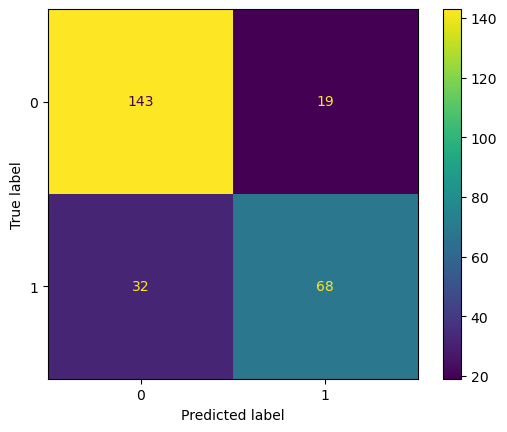

In [32]:
from xgboost import XGBClassifier
model_filter=XGBClassifier()
model_filter.fit(X_train,y_train)

y_pred=model_filter.predict(X_test)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
metric_filter=confusion_matrix(y_test,y_pred)

print (classification_report(y_test, y_pred))

cm = confusion_matrix( y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

# Feature Selection

## Filter Methods

#### Baixa Variância

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'body', 'body_null',
       'cabin_char', 'boat_char', '1', '2', '3', '5', '6', '7'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       162
           1       0.80      0.70      0.74       100

    accuracy                           0.82       262
   macro avg       0.81      0.79      0.80       262
weighted avg       0.82      0.82      0.81       262



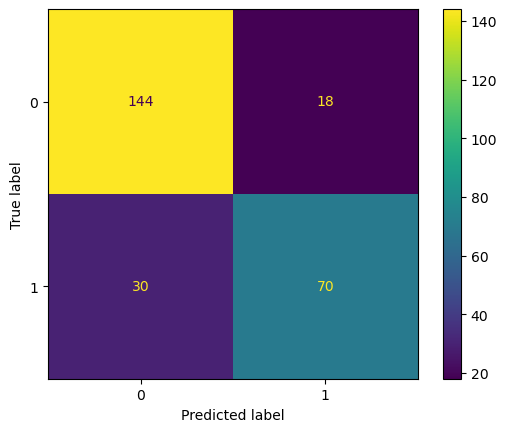

In [35]:

X_train_filter=X_train.copy()
y_train_filter=y_train.copy()
X_test_filter=X_test.copy()
y_test_filter=y_test.copy()

X_train_filter= X_train_filter.rename(str,axis="columns")
X_test_filter= X_test_filter.rename(str,axis="columns")

from sklearn.feature_selection import VarianceThreshold
sel=VarianceThreshold(threshold=0.01)
sel.fit(X_train_filter)
sel.transform(X_test_filter)

print(X_train_filter.columns[sel.get_support()])

del X_train_filter['4']
del X_test_filter['4']

from xgboost import XGBClassifier
model_filter=XGBClassifier()
model_filter.fit(X_train_filter,y_train_filter)

y_pred_filter=model_filter.predict(X_test_filter)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
metric_filter=confusion_matrix(y_test_filter,y_pred_filter)

print (classification_report(y_test, y_pred_filter))

cm = confusion_matrix( y_test, y_pred_filter)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

#### Método de correlação (variável alvo)

In [37]:
X_train_filter=X_train.copy()
y_train_filter=y_train.copy()
X_test_filter=X_test.copy()
y_test_filter=y_test.copy()

corrmat={}
for i in X_train_filter.columns.values:
    corrmat[i]=X_train_filter[i].corr(y_train_filter)

print(corrmat)

{'pclass': -0.3252302185340321, 'sex': 0.5195840223715701, 'age': -0.04598154015676826, 'sibsp': -0.02917869809430298, 'parch': 0.08100255657581484, 'fare': 0.24681291071699574, 'body': -0.20715411735798964, 'body_null': 0.24112549997283028, 'cabin_char': -0.2555007641133646, 'boat_char': 0.26240658718642623, 1: -0.5331648588810705, 2: 0.29572572486705745, 3: 0.06950703698438622, 4: -0.025953259131405816, 5: -0.1538701625690358, 6: 0.1827095081208424, 7: -0.01722107542712092}


              precision    recall  f1-score   support

           0       0.83      0.93      0.88       162
           1       0.86      0.70      0.77       100

    accuracy                           0.84       262
   macro avg       0.85      0.82      0.83       262
weighted avg       0.85      0.84      0.84       262



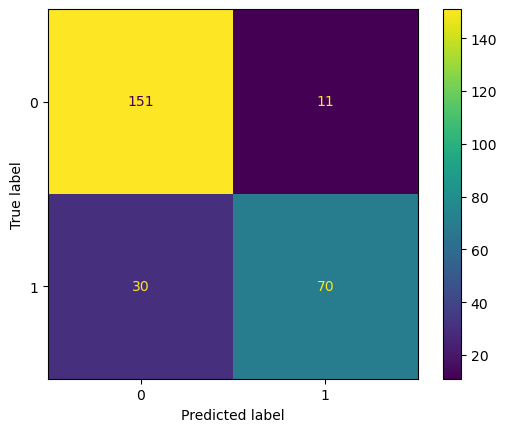

In [39]:
#Deleta correlação < 10%

del X_train_filter[7]
del X_train_filter[4]
del X_train_filter[3]
del X_train_filter['parch']
del X_train_filter['sibsp']
del X_train_filter['age']
del X_test_filter[7]
del X_test_filter[4]
del X_test_filter[3]
del X_test_filter['parch']
del X_test_filter['sibsp']
del X_test_filter['age']

from xgboost import XGBClassifier
model_filter=XGBClassifier()
model_filter.fit(X_train_filter,y_train_filter)


y_pred_filter=model_filter.predict(X_test_filter)

from sklearn.metrics import confusion_matrix
metric_filter=confusion_matrix(y_test_filter,y_pred_filter)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
metric_filter=confusion_matrix(y_test_filter,y_pred_filter)

print (classification_report(y_test, y_pred_filter))

cm = confusion_matrix( y_test, y_pred_filter)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

## Embedded methods

In [41]:
X_train_embedded=X_train.copy()
y_train_embedded=y_train.copy()
X_test_embedded=X_test.copy()
y_test_embedded=y_test.copy()

from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train_embedded,y_train_embedded)

feat_importance = xgb.feature_importances_ * 100

importance_dict = {}
for i, col in enumerate(X_train_embedded):
    importance_dict[col] = feat_importance[i]

print(importance_dict)


for i, (col, importance) in enumerate(importance_dict.items()):
    if importance < 1:
        X_train_embedded.drop(col, axis=1, inplace=True)
        X_test_embedded.drop(col, axis=1, inplace=True)
        print(f'del: {col}')

xgb=XGBClassifier()
xgb.fit(X_train_embedded,y_train_embedded)
y_pred_embedded=xgb.predict(X_test_embedded)

from sklearn.metrics import confusion_matrix
metric_embedded=confusion_matrix(y_test_embedded,y_pred_embedded)

accuracy_embedded=(metric_embedded[0][0]+metric_embedded[1][1])/sum(sum(metric_embedded))*100
print('Accuracy using embedded : ', accuracy_embedded)

{'pclass': 9.251349, 'sex': 0.7848993, 'age': 1.1481453, 'sibsp': 1.3563324, 'parch': 0.71916354, 'fare': 1.5831804, 'body': 7.141798, 'body_null': 0.0, 'cabin_char': 2.1598704, 'boat_char': 10.004859, 1: 50.45543, 2: 0.69663686, 3: 0.0, 4: 10.99631, 5: 1.5522586, 6: 1.0243107, 7: 1.1254547}
del: sex
del: parch
del: body_null
del: 2
del: 3
Accuracy using embedded :  83.20610687022901


## Wrapper methods

#### Forward feature selection

In [45]:

X_train_wrapper=X_train.copy()
y_train_wrapper=y_train.copy()
X_test_wrapper=X_test.copy()
y_test_wrapper=y_test.copy()

from xgboost import XGBClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
sfs1=SFS(XGBClassifier(n_jobs=4),k_features=9,forward=True,floating=False,verbose=2,scoring='roc_auc',cv=3)
sfs1.fit(np.array(X_train_wrapper),y_train_wrapper)


[2025-03-25 21:28:36] Features: 1/9 -- score: 0.77019998630345
[2025-03-25 21:28:37] Features: 2/9 -- score: 0.8350932062953351
[2025-03-25 21:28:37] Features: 3/9 -- score: 0.8677004702417722
[2025-03-25 21:28:38] Features: 4/9 -- score: 0.8867107604716987
[2025-03-25 21:28:38] Features: 5/9 -- score: 0.895342715888929
[2025-03-25 21:28:39] Features: 6/9 -- score: 0.8967499530318849
[2025-03-25 21:28:39] Features: 7/9 -- score: 0.898448153258176
[2025-03-25 21:28:40] Features: 8/9 -- score: 0.898448153258176
[2025-03-25 21:28:40] Features: 9/9 -- score: 0.8982514622943901

SequentialFeatureSelector(cv=3,
                          estimator=XGBClassifier(base_score=None, booster=None,
                                                  callbacks=None,
                                                  colsample_bylevel=None,
                                                  colsample_bynode=None,
                                                  colsample_bytree=None,
                                                  device=None,
                                                  early_stopping_rounds=None,
                                                  enable_categorical=False,
                                                  eval_metric=None,
                                                  feature_types=None,
                                                  feature_weights=None,
                                                  gamma=None, grow_policy=None,
                                                  importance_type=None,
                                                  interaction_constraints=None,
                                                  learning_rate=None,
                                                  max_bin=None,
                                                  max_cat_threshold=None,
                                                  max_cat_to_onehot=None,
                                                  max_delta_step=None,
                                                  max_depth=None,
                                                  max_leaves=None,
                                                  min_child_weight=None,
                                                  missing=nan,
                                                  monotone_constraints=None,
                                                  multi_strategy=None,
                                                  n_estimators=None, n_jobs=4,
                                                  num_parallel_tree=None, ...),
                          k_features=(9, 9), scoring='roc_auc', verbose=2)

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       162
           1       0.84      0.69      0.76       100

    accuracy                           0.83       262
   macro avg       0.83      0.80      0.81       262
weighted avg       0.83      0.83      0.83       262



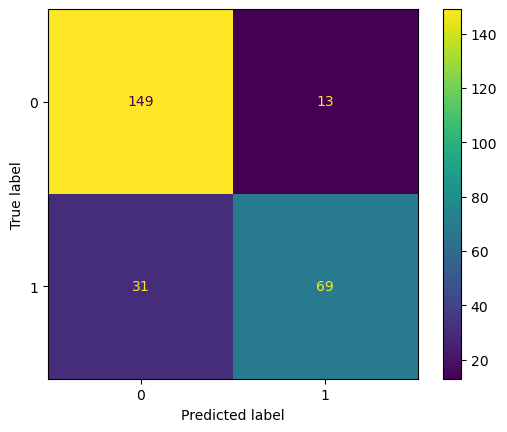

In [47]:
x_train_forward=sfs1.transform(X_train_wrapper)
x_test_forward=sfs1.transform(X_test_wrapper)

from xgboost import XGBClassifier
model_forward=XGBClassifier()
model_forward.fit(x_train_forward,y_train_wrapper)

y_pred_forward=model_forward.predict(x_test_forward)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
metric_filter=confusion_matrix(y_test_wrapper,y_pred_forward)
print (classification_report(y_test_wrapper, y_pred_forward))

cm = confusion_matrix( y_test_wrapper, y_pred_forward)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

#### Backward feature selection

In [49]:
X_train_wrapper=X_train.copy()
y_train_wrapper=y_train.copy()
X_test_wrapper=X_test.copy()
y_test_wrapper=y_test.copy()
from xgboost import XGBClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
sfs2=SFS(XGBClassifier(n_jobs=4),k_features=5,forward=False,floating=False,verbose=2,scoring='roc_auc',cv=3)
sfs2.fit(np.array(X_train_wrapper),y_train_wrapper)


[2025-03-25 21:29:13] Features: 16/5 -- score: 0.889904536319265
[2025-03-25 21:29:14] Features: 15/5 -- score: 0.8927729965509247
[2025-03-25 21:29:14] Features: 14/5 -- score: 0.8933823399822657
[2025-03-25 21:29:15] Features: 13/5 -- score: 0.8949951079377388
[2025-03-25 21:29:16] Features: 12/5 -- score: 0.8978614380514
[2025-03-25 21:29:16] Features: 11/5 -- score: 0.8995817876385205
[2025-03-25 21:29:17] Features: 10/5 -- score: 0.8996627780353735
[2025-03-25 21:29:17] Features: 9/5 -- score: 0.8996627780353735
[2025-03-25 21:29:17] Features: 8/5 -- score: 0.8986216380584047
[2025-03-25 21:29:18] Features: 7/5 -- score: 0.8977221350198873
[2025-03-25 21:29:18] Features: 6/5 -- score: 0.8956628961040808
[2025-03-25 21:29:18] Features: 5/5 -- score: 0.895342715888929

SequentialFeatureSelector(cv=3,
                          estimator=XGBClassifier(base_score=None, booster=None,
                                                  callbacks=None,
                                                  colsample_bylevel=None,
                                                  colsample_bynode=None,
                                                  colsample_bytree=None,
                                                  device=None,
                                                  early_stopping_rounds=None,
                                                  enable_categorical=False,
                                                  eval_metric=None,
                                                  feature_types=None,
                                                  feature_weights=None,
                                                  gamma=None, grow_policy=None,
                                                  importance_type=None,
                                                  interaction_constraints=None,
                                                  learning_rate=None,
                                                  max_bin=None,
                                                  max_cat_threshold=None,
                                                  max_cat_to_onehot=None,
                                                  max_delta_step=None,
                                                  max_depth=None,
                                                  max_leaves=None,
                                                  min_child_weight=None,
                                                  missing=nan,
                                                  monotone_constraints=None,
                                                  multi_strategy=None,
                                                  n_estimators=None, n_jobs=4,
                                                  num_parallel_tree=None, ...),
                          forward=False, k_features=(5, 5), scoring='roc_auc',
                          verbose=2)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       162
           1       0.83      0.72      0.77       100

    accuracy                           0.84       262
   macro avg       0.83      0.81      0.82       262
weighted avg       0.84      0.84      0.83       262



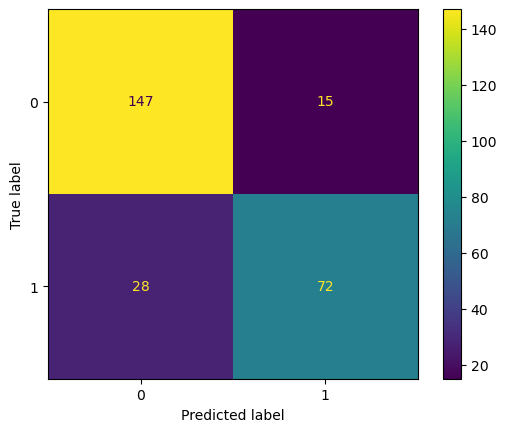

In [51]:
x_train_backward=sfs2.transform(X_train_wrapper)
x_test_backward=sfs2.transform(X_test_wrapper)

from xgboost import XGBClassifier
model_backward=XGBClassifier()
model_backward.fit(x_train_backward,y_train_wrapper)

y_pred_backward=model_backward.predict(x_test_backward)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
metric_filter=confusion_matrix(y_test_wrapper,y_pred_backward)
print (classification_report(y_test_wrapper, y_pred_backward))

cm = confusion_matrix( y_test_wrapper, y_pred_backward)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

#### Exhaustive feature selection


In [53]:
X_train_wrapper=X_train.copy()
y_train_wrapper=y_train.copy()
X_test_wrapper=X_test.copy()
y_test_wrapper=y_test.copy()

from xgboost import XGBClassifier
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
sfs3=EFS(XGBClassifier(n_jobs=4),min_features=1,max_features=3,scoring='roc_auc',print_progress=True,cv=2)
sfs3.fit(np.array(X_train_wrapper),y_train_wrapper)

Features: 833/833

ExhaustiveFeatureSelector(cv=2,
                          estimator=XGBClassifier(base_score=None, booster=None,
                                                  callbacks=None,
                                                  colsample_bylevel=None,
                                                  colsample_bynode=None,
                                                  colsample_bytree=None,
                                                  device=None,
                                                  early_stopping_rounds=None,
                                                  enable_categorical=False,
                                                  eval_metric=None,
                                                  feature_types=None,
                                                  feature_weights=None,
                                                  gamma=None, grow_policy=None,
                                                  importance_type=None,
                                                  interaction_co...
                                                  max_cat_threshold=None,
                                                  max_cat_to_onehot=None,
                                                  max_delta_step=None,
                                                  max_depth=None,
                                                  max_leaves=None,
                                                  min_child_weight=None,
                                                  missing=nan,
                                                  monotone_constraints=None,
                                                  multi_strategy=None,
                                                  n_estimators=None, n_jobs=4,
                                                  num_parallel_tree=None, ...),
                          feature_groups=[[0], [1], [2], [3], [4], [5], [6],
                                          [7], [8], [9], [10], [11], [12], [13],
                                          [14], [15], [16]],
                          max_features=3, scoring='roc_auc')

## Statistical Filter Methods

#### Ganho de Informação (Informação mútua)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       162
           1       0.78      0.73      0.76       100

    accuracy                           0.82       262
   macro avg       0.81      0.80      0.81       262
weighted avg       0.82      0.82      0.82       262



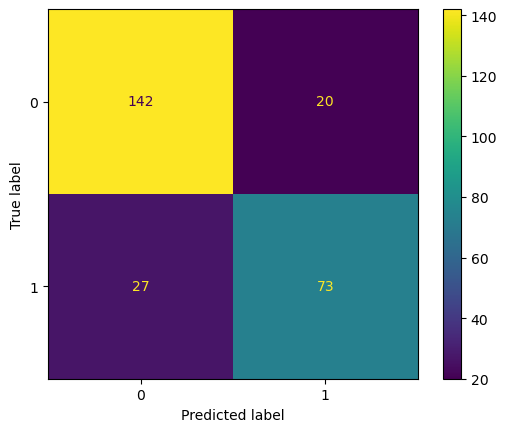

In [54]:
X_train_filter=X_train.copy()
y_train_filter=y_train.copy()
X_test_filter=X_test.copy()
y_test_filter=y_test.copy()

X_train_filter= X_train_filter.rename(str,axis="columns")
X_test_filter= X_test_filter.rename(str,axis="columns")

from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.feature_selection import SelectKBest,SelectPercentile
#mi=mutual_info_classif(X_train_filter,y_train_filter)
select=SelectKBest(mutual_info_classif,k=12).fit(X_train_filter,y_train_filter)
X_train_filter=X_train_filter[X_train_filter.columns[select.get_support()].values]
X_test_filter=X_test_filter[X_test_filter.columns[select.get_support()].values]

from xgboost import XGBClassifier
model_filter=XGBClassifier()
model_filter.fit(X_train_filter,y_train_filter)


y_pred_filter=model_filter.predict(X_test_filter)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
metric_filter=confusion_matrix(y_test_filter,y_pred_filter)

print (classification_report(y_test, y_pred_filter))

cm = confusion_matrix( y_test, y_pred_filter)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

#### Score de Fisher

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       162
           1       0.85      0.73      0.78       100

    accuracy                           0.85       262
   macro avg       0.85      0.82      0.83       262
weighted avg       0.85      0.85      0.84       262



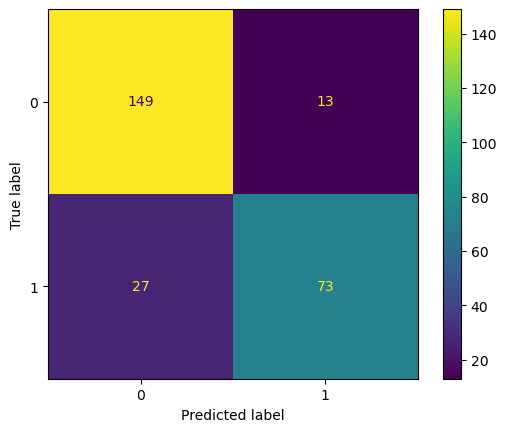

In [55]:
X_train_filter=X_train.copy()
y_train_filter=y_train.copy()
X_test_filter=X_test.copy()
y_test_filter=y_test.copy()

X_train_filter= X_train_filter.rename(str,axis="columns")
X_test_filter= X_test_filter.rename(str,axis="columns")

from sklearn.feature_selection import SelectKBest, chi2
select=SelectKBest(chi2,k=10).fit(X_train_filter,y_train_filter)
X_train_filter=X_train_filter[X_train_filter.columns[select.get_support()].values]
X_test_filter=X_test_filter[X_test_filter.columns[select.get_support()].values]
from xgboost import XGBClassifier
model_filter=XGBClassifier()
model_filter.fit(X_train_filter,y_train_filter)


y_pred_filter=model_filter.predict(X_test_filter)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
metric_filter=confusion_matrix(y_test_filter,y_pred_filter)

print (classification_report(y_test, y_pred_filter))

cm = confusion_matrix( y_test, y_pred_filter)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

#### Univariado (Anova)

              precision    recall  f1-score   support

           0       0.83      0.93      0.88       162
           1       0.86      0.70      0.77       100

    accuracy                           0.84       262
   macro avg       0.85      0.82      0.83       262
weighted avg       0.85      0.84      0.84       262



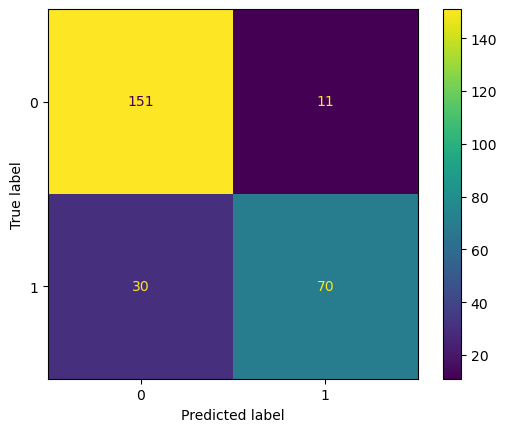

In [56]:
X_train_filter=X_train.copy()
y_train_filter=y_train.copy()
X_test_filter=X_test.copy()
y_test_filter=y_test.copy()

X_train_filter= X_train_filter.rename(str,axis="columns")
X_test_filter= X_test_filter.rename(str,axis="columns")

from sklearn.feature_selection import SelectKBest, f_classif
select=SelectKBest(f_classif,k=11).fit(X_train_filter,y_train_filter)
X_train_filter=X_train_filter[X_train_filter.columns[select.get_support()].values]
X_test_filter=X_test_filter[X_test_filter.columns[select.get_support()].values]

from xgboost import XGBClassifier
model_filter=XGBClassifier()
model_filter.fit(X_train_filter,y_train_filter)


y_pred_filter=model_filter.predict(X_test_filter)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
metric_filter=confusion_matrix(y_test_filter,y_pred_filter)

print (classification_report(y_test, y_pred_filter))

cm = confusion_matrix( y_test, y_pred_filter)
disp = ConfusionMatrixDisplay(cm)
disp.plot()